<a href="https://colab.research.google.com/github/young-suh/ESAA_2026/blob/main/YB_0918(1)_exercises_chipotle_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [2]:
chipo = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv', sep = '\t')

### Step 4. See the first 10 entries

In [3]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

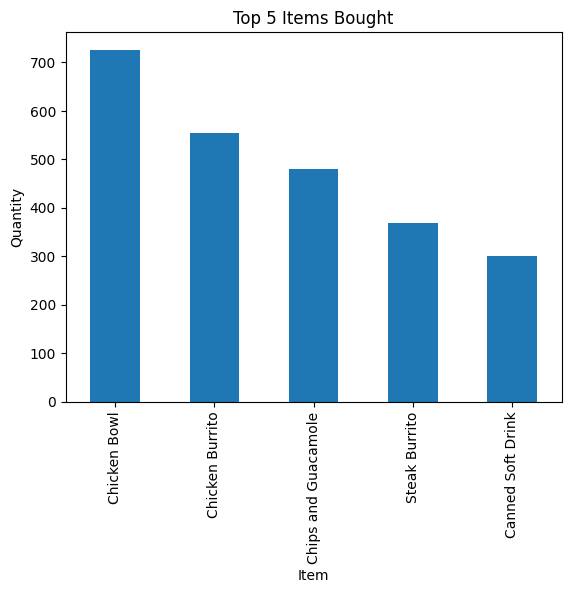

In [4]:
# 상위 5개 구매 상품
top5 = chipo['item_name'].value_counts().head(5)

# 그래프
top5.plot(kind='bar')

plt.xlabel('Item')
plt.ylabel('Quantity')
plt.title('Top 5 Items Bought')

plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

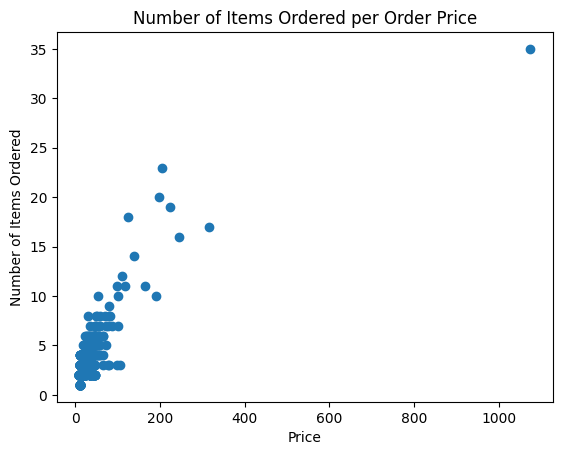

In [5]:
# $ 제거 후 숫자변환
chipo['item_price'] = chipo['item_price'].str.replace('$', '').astype(float)

# total price
chipo['total_price'] = chipo['quantity'] * chipo['item_price']

# variable
price = chipo.groupby('order_id')['total_price'].sum()
items = chipo.groupby('order_id')['quantity'].sum()

# 그래프
plt.scatter(price, items)

plt.xlabel('Price')
plt.ylabel('Number of Items Ordered')
plt.title('Number of Items Ordered per Order Price')

plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

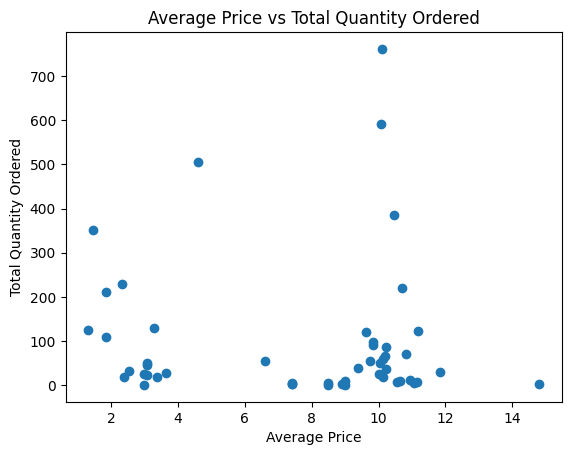

In [6]:
# 가격이 비싼 상품일수록 주문량이 적을까?

# variable
price = chipo.groupby('item_name')['item_price'].mean()
quantity = chipo.groupby('item_name')['quantity'].sum()

# graph
plt.scatter(price, quantity)

plt.xlabel('Average Price')
plt.ylabel('Total Quantity Ordered')
plt.title('Average Price vs Total Quantity Ordered')

plt.show()